In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/cancer-risk-factors.csv")

In [4]:
df.head()

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [ ]:
df.columns

Index(['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use',
       'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed',
       'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution',
       'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection',
       'Calcium_Intake', 'Overall_Risk_Score', 'BMI',
       'Physical_Activity_Level', 'Risk_Level'],
      dtype='object')

## Identification

-Patient ID
-Cancer Type

## General Characters

- Age
- Gender
- BMI

## Lifestyle and Environmental Factors

- Smoking
- Alcohol use
- Obesity
- Diet Red Meat
- Diet Salter Processes
- Fruit & Veg intake
- Physical Activities
- Air Pollution
- Occupational Hazard
- Calcium Intake
_ Physical Activity Level

## Medical Factors

- Family History
- BRCA_Mutation
- H_Pylori_Infection

## Engineered (Calculated Features)

- Overall Risk Score
- Risk Level

## To Predict - Risk Level

Understanding the Dataset by EDA

In [ ]:
risk_counts = df["Risk_Level"].value_counts()
risk_counts

,count
Risk_Level,
Medium,1574
Low,324
High,102


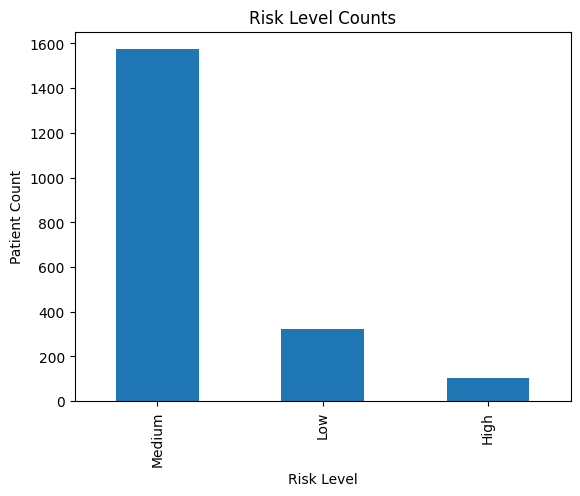

In [6]:
df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Counts")
plt.xlabel("Risk Level")
plt.ylabel("Patient Count")
plt.show()

## The data is highly imbalance
- Low - 16.2%
- Medium - 78.7%
- High - 5.1%


In [ ]:
df["Gender"].value_counts()

,count
Gender,
0,1022
1,978


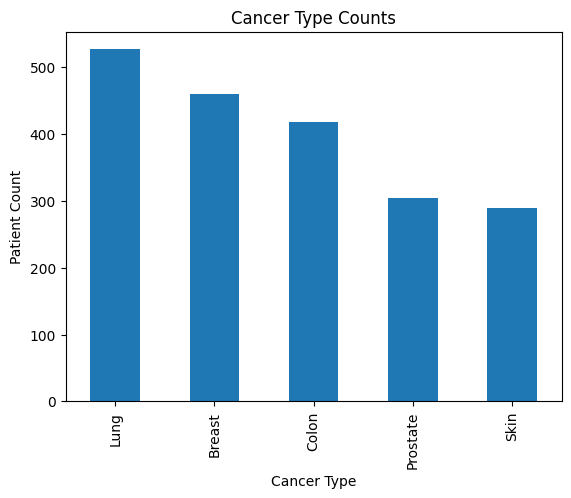

In [7]:
df["Cancer_Type"].value_counts().plot(kind="bar")
plt.title("Cancer Type Counts")
plt.xlabel("Cancer Type")
plt.ylabel("Patient Count")
plt.show()

In [ ]:
gender_cancer_counts = df.groupby(["Gender", "Cancer_Type"]).size().reset_index(name="Patient_counts")
gender_cancer_counts["Gender"] = gender_cancer_counts["Gender"].map({0:"Female", 1: "Male"})
print(gender_cancer_counts)

   Gender Cancer_Type  Patient_counts
0  Female      Breast             455
1  Female       Colon             197
2  Female        Lung             238
3  Female        Skin             132
4    Male      Breast               5
5    Male       Colon             221
6    Male        Lung             289
7    Male    Prostate             305
8    Male        Skin             158


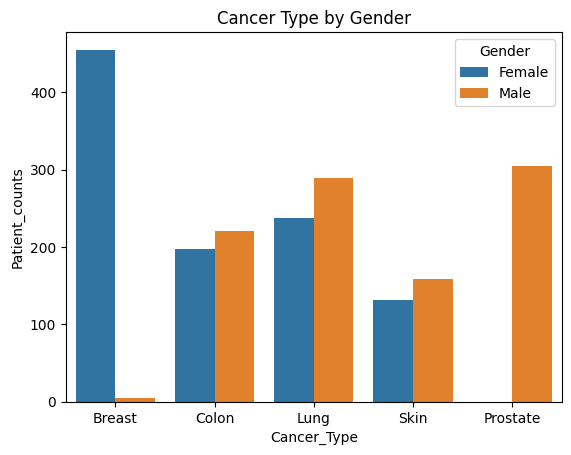

In [ ]:
sns.barplot(data=gender_cancer_counts, x="Cancer_Type", y="Patient_counts", hue="Gender")
plt.title("Cancer Type by Gender")
plt.show()

In [8]:
#find all patients less than 35

less_than_35 = df[df["Age"] < 35]
less_than_35

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
420,BR0020,Skin,32,0,1,3,8,0,5,1,...,0,4,4,0,0,3,0.283988,34.2,1,Low
433,BR0033,Lung,25,0,8,6,5,0,3,5,...,5,8,9,0,0,3,0.550154,28.9,8,Medium
454,BR0054,Lung,29,0,8,6,7,0,3,0,...,0,7,2,0,0,2,0.412898,23.9,6,Medium
468,BR0068,Lung,32,0,8,2,0,0,1,9,...,0,8,2,0,0,2,0.338060,23.9,2,Medium
495,BR0095,Breast,31,0,1,9,10,0,8,5,...,4,0,4,0,0,0,0.421680,28.2,6,Medium
585,BR0185,Lung,34,0,6,8,5,0,3,1,...,3,8,4,0,1,2,0.516405,27.0,3,Medium
593,BR0193,Breast,34,0,5,1,10,1,1,8,...,5,4,5,1,0,4,0.468496,27.3,0,Medium
621,BR0221,Lung,25,0,7,10,6,0,2,7,...,4,7,10,0,0,0,0.583443,27.9,4,Medium
698,BR0298,Lung,34,0,8,0,2,0,0,0,...,1,7,5,0,1,1,0.246356,29.7,9,Low


In [11]:
young_cancer_type= df[df["Age"]<35]["Cancer_Type"].value_counts()
young_cancer_type

,count
Cancer_Type,
Lung,6
Breast,2
Skin,1


In [14]:
df[df["Age"]<35]["Risk_Level"].value_counts()

,count
Risk_Level,
Medium,7
Low,2


In [15]:
## finding out which factors contribute to high risk cancer

#select only numerical values
numerical_columns = df.select_dtypes(include="number").columns

#compute the mean of each numeric feature per risk level
risk_means = df.groupby("Risk_Level")[numerical_columns].mean().T
risk_means

Risk_Level,High,Low,Medium
Age,63.745098,63.685185,63.125794
Gender,0.509804,0.493827,0.486658
Smoking,7.519608,2.845679,5.479670
Alcohol_Use,7.519608,2.984568,5.296061
Obesity,7.274510,4.824074,6.118170
Family_History,0.205882,0.138889,0.205210
Diet_Red_Meat,7.362745,3.972222,5.299238
Diet_Salted_Processed,7.039216,2.888889,4.747776
Fruit_Veg_Intake,3.911765,5.666667,4.841169
Physical_Activity,4.921569,3.669753,4.027319


## Insights

- Lifestyle/ Habits such as smoking, alcohol consumption, obesity, red meat and processed food consumption are at high risk level to get cancer.

- Air Pollution, which is an evironmental factor also contribte to high risk level.

- Occupation Hazards can also contribute in high risk level.
- Consumption of vegetables, fruits reduces the risk level.
- Physical Avtivities also reduces the risk level.

In [16]:
risk_diff = risk_means["High"] - risk_means["Low"]
risk_diff = risk_diff.sort_values(ascending=False)
risk_diff

,0
Air_Pollution,5.591685
Smoking,4.673929
Alcohol_Use,4.535040
Diet_Salted_Processed,4.150327
Occupational_Hazards,3.625999
Diet_Red_Meat,3.390523
Obesity,2.450436
Physical_Activity,1.251816
Calcium_Intake,0.672295
Overall_Risk_Score,0.430533


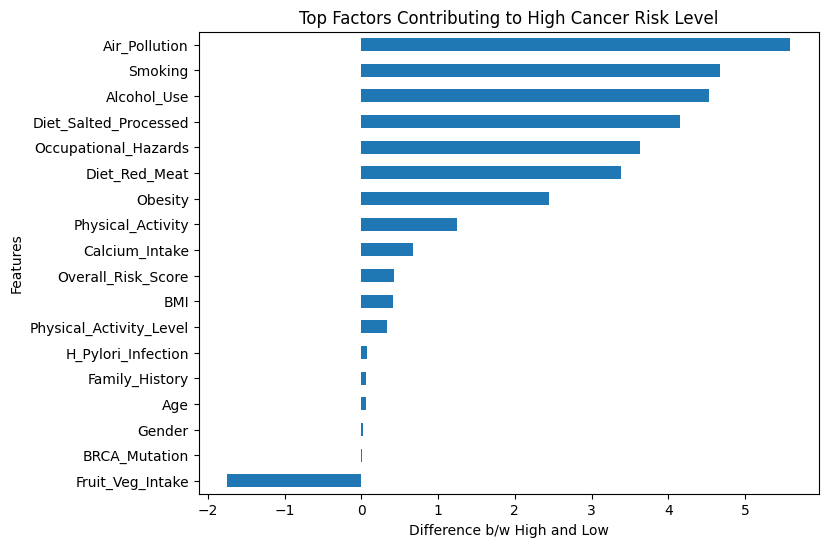

In [17]:
risk_diff.sort_values(ascending=True).plot(kind="barh", figsize=(8,6), title= "Top Factors Contributing to High Cancer Risk Level")
plt.xlabel("Difference b/w High and Low")
plt.ylabel("Features")
plt.show()

Air Pollution, Smoking and Alcohol Use is the top 3 features contributing to High Risk Level.

## Univariate Analysis

In [ ]:
df.head(2)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium


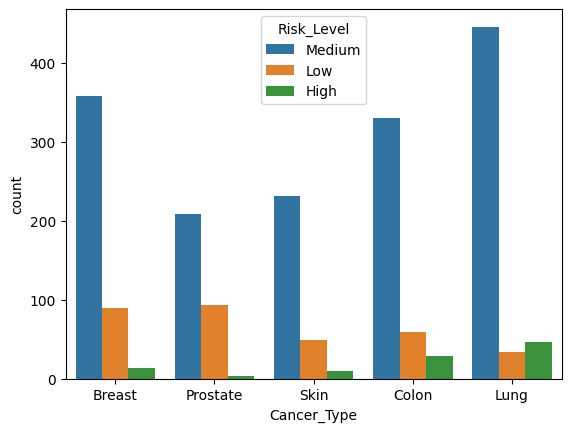

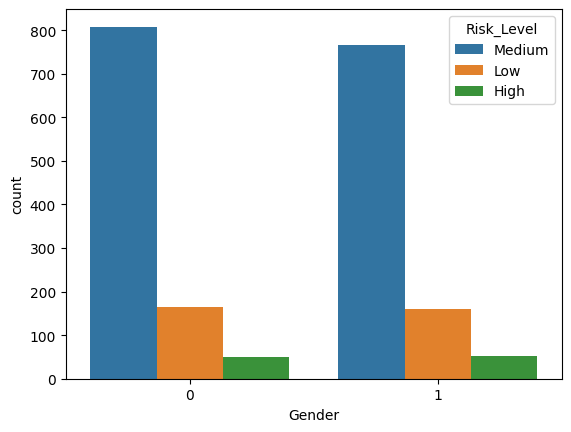

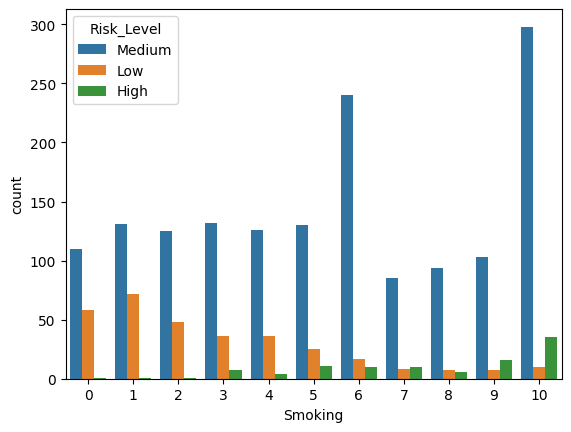

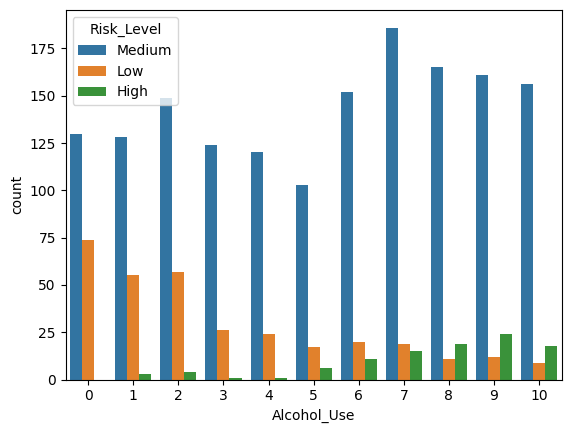

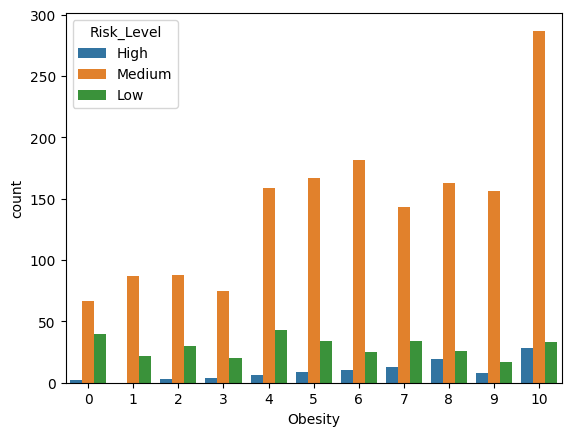

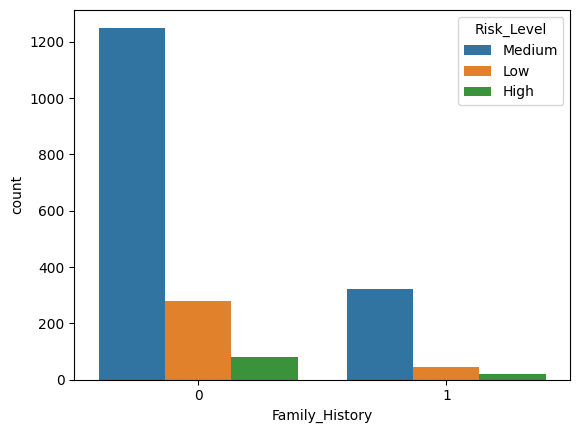

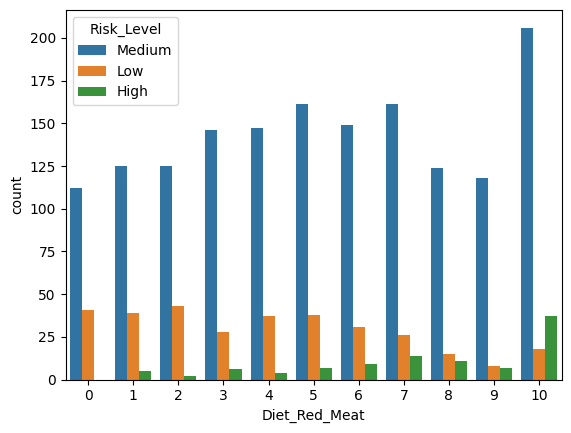

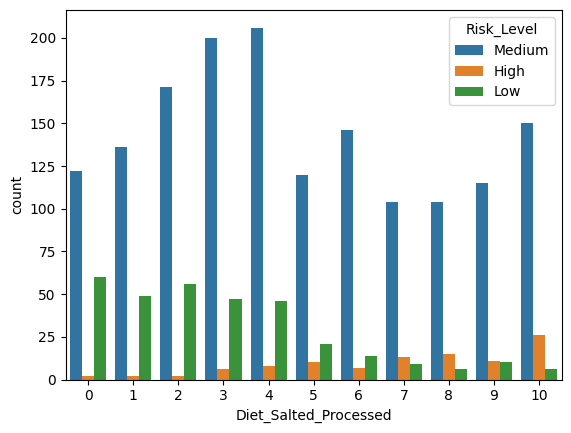

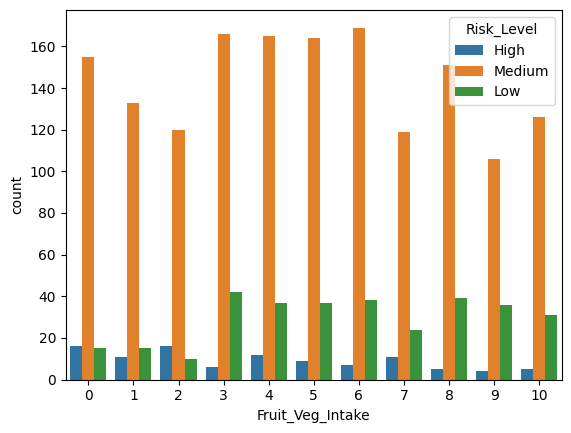

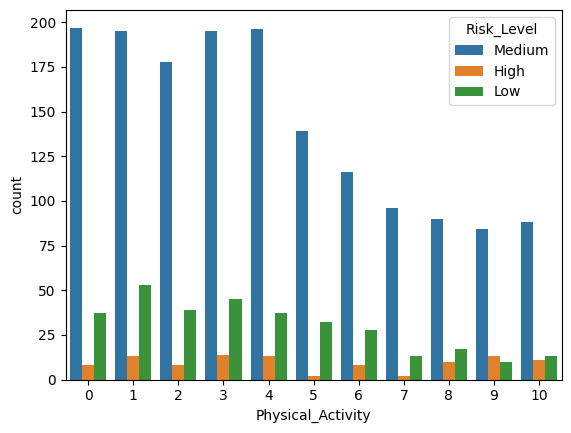

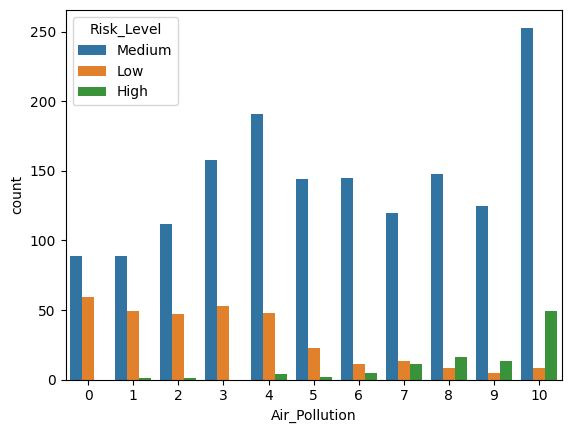

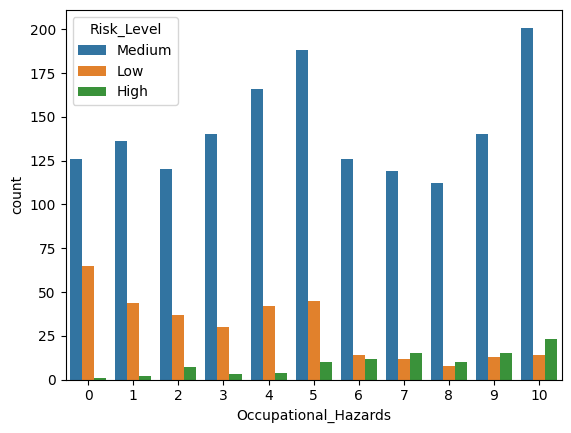

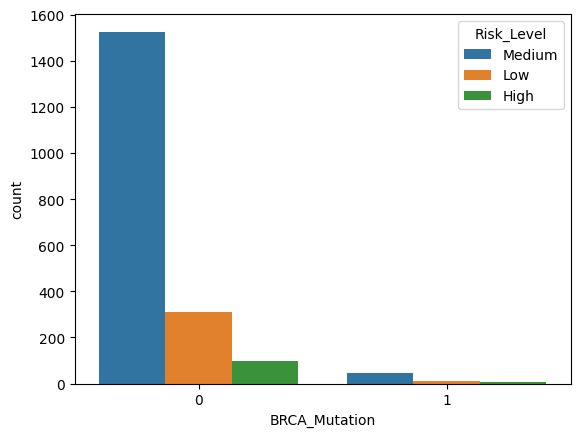

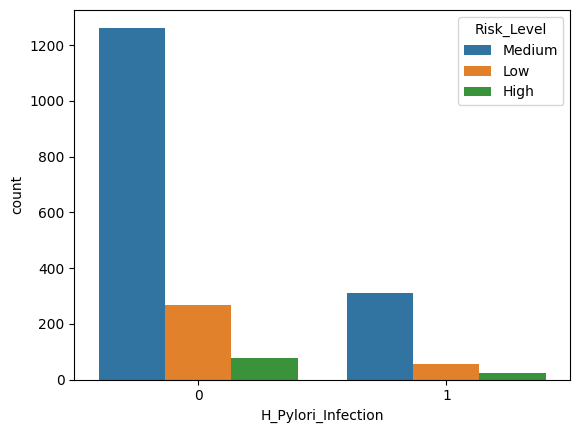

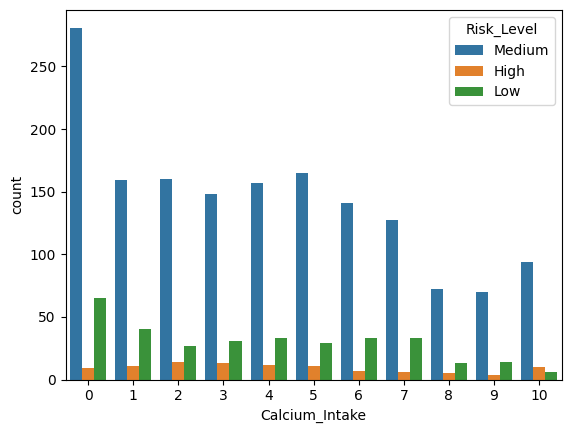

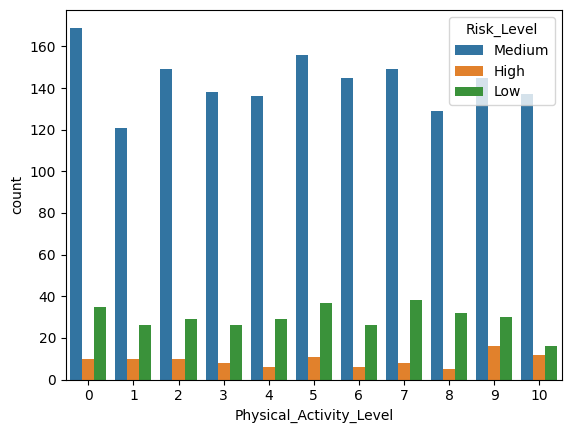

In [ ]:
for i, predictor in enumerate(df.drop(columns=["Patient_ID", "Age", "Overall_Risk_Score", "BMI", "Risk_Level"])):
  plt.figure(i)
  sns.countplot(data=df, x=predictor, hue="Risk_Level")

## Numerical Analysis

In [ ]:
df.head(2)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium


In [ ]:
df = df.drop(columns=["Patient_ID"])

In [ ]:
df.head(2)

,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,Breast,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,Prostate,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9,Medium


In [ ]:
df_dummies = pd.get_dummies(df)
df_dummies

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,...,BMI,Physical_Activity_Level,Cancer_Type_Breast,Cancer_Type_Colon,Cancer_Type_Lung,Cancer_Type_Prostate,Cancer_Type_Skin,Risk_Level_High,Risk_Level_Low,Risk_Level_Medium
0,68,0,7,2,8,0,5,3,7,4,...,28.0,5,True,False,False,False,False,False,False,True
1,74,1,8,9,8,0,0,3,7,1,...,25.4,9,False,False,False,True,False,False,False,True
2,55,1,7,10,7,0,3,3,4,1,...,28.6,2,False,False,False,False,True,False,False,True
3,61,0,6,2,2,0,6,2,4,6,...,32.1,7,False,True,False,False,False,False,True,False
4,67,1,10,7,4,0,6,3,10,9,...,25.1,2,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,60,1,4,6,4,0,10,6,4,4,...,30.3,3,False,True,False,False,False,False,False,True
1996,84,1,5,7,8,0,10,0,1,2,...,25.9,4,False,False,False,True,False,False,False,True
1997,65,0,7,2,10,0,4,2,2,3,...,22.5,3,False,False,True,False,False,False,True,False
1998,64,1,10,2,10,0,2,10,7,5,...,25.3,3,False,False,True,False,False,False,False,True


In [ ]:
plt.figure(figsize=(10,8))
df_dummies.corr()["Risk_Level"].sort_values(ascending=False).plot(kind="bar")

KeyError: 'Risk_Level'

<Figure size 1000x800 with 0 Axes>